# 01. EDA — AI4I 2020 Predictive Maintenance

**목적**
- 데이터 품질 확인 (결측치, 라벨 일관성)
- 고장 비율과 불균형 정도 파악
- 센서값 분포, 정상/고장 간 차이
- 제품 타입(L/M/H)별 차이

파생변수 분석은 `02_features.ipynb`에서 이어간다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

## 1. 로드 및 컬럼명 정리

원본 파일에 UTF-8 BOM이 있으므로 `utf-8-sig`로 읽는다. 컬럼명은 백엔드 코드와 같은 이름으로 바꾼다.

In [2]:
raw = pd.read_csv("../../data/ai4i2020.csv", encoding="utf-8-sig")

COLUMNS = {
    "UDI": "udi",
    "Product ID": "productId",
    "Type": "productType",
    "Air temperature [K]": "airTemp",
    "Process temperature [K]": "processTemp",
    "Rotational speed [rpm]": "rotSpeed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "toolWear",
    "Machine failure": "machineFailure",
}
df = raw.rename(columns=COLUMNS)

SENSORS = ["airTemp", "processTemp", "rotSpeed", "torque", "toolWear"]
FAILURE_TYPES = ["TWF", "HDF", "PWF", "OSF", "RNF"]
TYPE_ORDER = ["L", "M", "H"]

print(df.shape)
df.head()

(10000, 14)


,udi,productId,productType,airTemp,processTemp,rotSpeed,torque,toolWear,machineFailure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. 데이터 품질

In [3]:
print("결측치 합계:", int(df.isna().sum().sum()))
print("중복 행:", int(df.duplicated().sum()))
print("udi 고유값:", df["udi"].nunique(), "/ productId 고유값:", df["productId"].nunique())
df.dtypes

결측치 합계: 0
중복 행: 0
udi 고유값: 10000 / productId 고유값: 10000


udi                 int64
productId             str
productType           str
airTemp           float64
processTemp       float64
rotSpeed            int64
torque            float64
toolWear            int64
machineFailure      int64
TWF                 int64
HDF                 int64
PWF                 int64
OSF                 int64
RNF                 int64
dtype: object

In [4]:
df[SENSORS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
airTemp,10000.0,300.00,2.00,295.3,298.3,300.1,301.5,304.5
processTemp,10000.0,310.01,1.48,305.7,308.8,310.1,311.1,313.8
rotSpeed,10000.0,1538.78,179.28,1168.0,1423.0,1503.0,1612.0,2886.0
torque,10000.0,39.99,9.97,3.8,33.2,40.1,46.8,76.6
toolWear,10000.0,107.95,63.65,0.0,53.0,108.0,162.0,253.0


## 3. 고장 비율 (불균형)

In [5]:
n = len(df)
summary = pd.DataFrame({
    "count": df[["machineFailure"] + FAILURE_TYPES].sum(),
})
summary["ratio(%)"] = (summary["count"] / n * 100).round(2)
summary

,count,ratio(%)
machineFailure,339,3.39
TWF,46,0.46
HDF,115,1.15
PWF,95,0.95
OSF,98,0.98
RNF,19,0.19


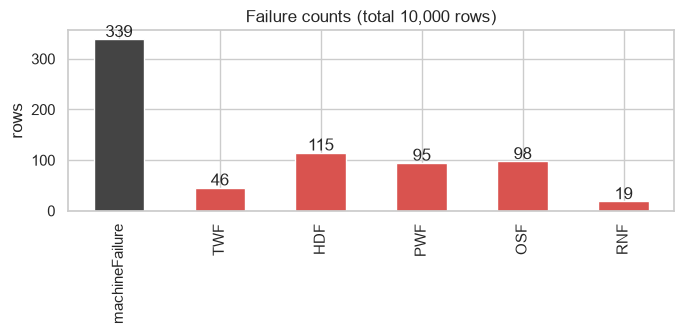

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
summary["count"].plot.bar(ax=ax, color=["#444"] + ["#d9534f"] * 5)
for i, v in enumerate(summary["count"]):
    ax.text(i, v + 4, str(v), ha="center")
ax.set_title("Failure counts (total 10,000 rows)")
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()

## 4. 라벨 일관성

`machineFailure`와 유형별 라벨(TWF~RNF)이 항상 일치하는지 확인한다.

In [7]:
df["nTypeLabels"] = df[FAILURE_TYPES].sum(axis=1)
pd.crosstab(df["machineFailure"], df["nTypeLabels"], margins=True)

nTypeLabels,0,1,2,3,All
machineFailure,,,,,
0,9643,18,0,0,9661
1,9,306,23,1,339
All,9652,324,23,1,10000


### 4-1. 고장(1)인데 유형 라벨이 없는 행

In [8]:
df.loc[(df["machineFailure"] == 1) & (df["nTypeLabels"] == 0), ["udi", "productType"] + SENSORS]

,udi,productType,airTemp,processTemp,rotSpeed,torque,toolWear
1437,1438,H,298.8,309.9,1439,45.2,40
2749,2750,M,299.7,309.2,1685,28.9,179
4044,4045,M,301.9,310.9,1419,47.7,20
4684,4685,M,303.6,311.8,1421,44.8,101
5536,5537,M,302.3,311.8,1363,54.0,119
5941,5942,L,300.6,310.7,1438,48.5,78
6478,6479,L,300.5,309.8,1663,29.1,145
8506,8507,L,298.4,309.6,1710,27.3,163
9015,9016,L,297.2,308.1,1431,49.7,210


### 4-2. 유형 라벨이 있는데 고장(0)인 행

In [9]:
mismatch = df[(df["machineFailure"] == 0) & (df["nTypeLabels"] > 0)]
print(mismatch[FAILURE_TYPES].sum())
mismatch[["udi", "productType"] + SENSORS + FAILURE_TYPES].head(10)

TWF     0
HDF     0
PWF     0
OSF     0
RNF    18
dtype: int64


,udi,productType,airTemp,processTemp,rotSpeed,torque,toolWear,TWF,HDF,PWF,OSF,RNF
1221,1222,M,297.0,308.3,1399,46.4,132,0,0,0,0,1
1302,1303,L,298.6,309.8,1505,45.7,144,0,0,0,0,1
1748,1749,H,298.4,307.7,1626,31.1,166,0,0,0,0,1
2072,2073,L,299.6,309.5,1570,35.5,189,0,0,0,0,1
2559,2560,L,299.3,309.0,1447,50.4,140,0,0,0,0,1
3065,3066,M,300.1,309.2,1687,27.7,95,0,0,0,0,1
3452,3453,H,301.6,310.5,1602,32.3,2,0,0,0,0,1
5471,5472,L,302.7,312.3,1346,61.2,170,0,0,0,0,1
5489,5490,L,302.6,312.1,1499,35.0,215,0,0,0,0,1
5495,5496,H,302.9,312.5,1357,55.0,12,0,0,0,0,1


### 4-3. 여러 유형이 동시에 발생한 행

In [10]:
multi = df[df["nTypeLabels"] >= 2]
combo = multi[FAILURE_TYPES].apply(lambda r: "+".join(t for t in FAILURE_TYPES if r[t] == 1), axis=1)
combo.value_counts()

PWF+OSF        11
HDF+OSF         6
HDF+PWF         3
TWF+OSF         2
TWF+RNF         1
TWF+PWF+OSF     1
Name: count, dtype: int64

## 5. 센서값 분포 (정상 vs 고장)

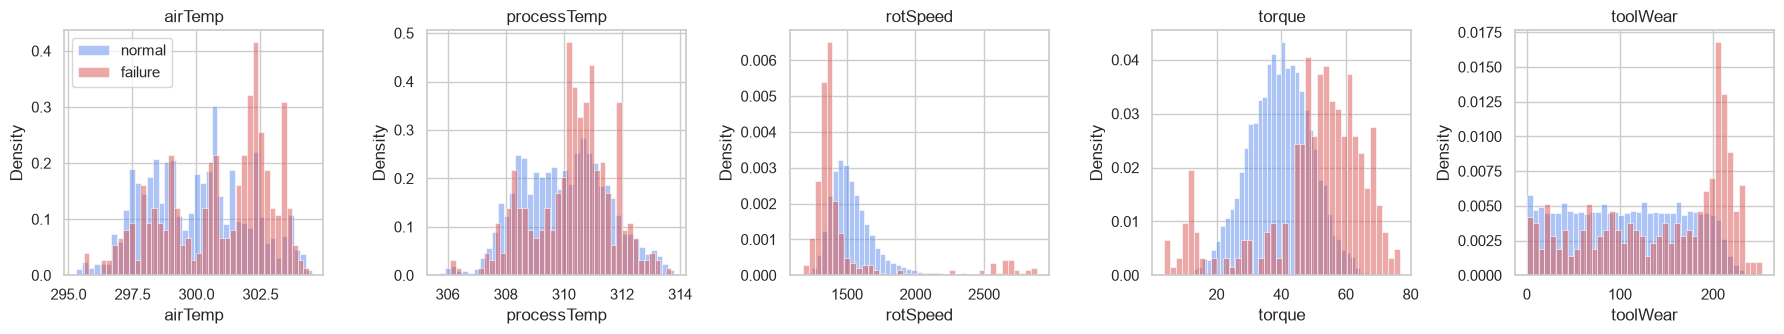

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, SENSORS):
    sns.histplot(df[df["machineFailure"] == 0], x=col, ax=ax, stat="density", color="#5b8def", alpha=0.5, label="normal", bins=40)
    sns.histplot(df[df["machineFailure"] == 1], x=col, ax=ax, stat="density", color="#d9534f", alpha=0.5, label="failure", bins=40)
    ax.set_title(col)
axes[0].legend()
plt.tight_layout()
plt.show()

In [12]:
df.groupby("machineFailure")[SENSORS].mean().T.round(1)

machineFailure,0,1
airTemp,300.0,300.9
processTemp,310.0,310.3
rotSpeed,1540.3,1496.5
torque,39.6,50.2
toolWear,106.7,143.8


## 6. 제품 타입(L/M/H)별 차이

In [13]:
by_type = df.groupby("productType").agg(
    rows=("udi", "size"),
    failures=("machineFailure", "sum"),
)
by_type["failureRate(%)"] = (by_type["failures"] / by_type["rows"] * 100).round(2)
by_type = by_type.join(df.groupby("productType")[FAILURE_TYPES].sum())
by_type.loc[TYPE_ORDER]

,rows,failures,failureRate(%),TWF,HDF,PWF,OSF,RNF
productType,,,,,,,,
L,6000,235,3.92,25,76,59,87,13
M,2997,83,2.77,14,31,31,9,2
H,1003,21,2.09,7,8,5,2,4


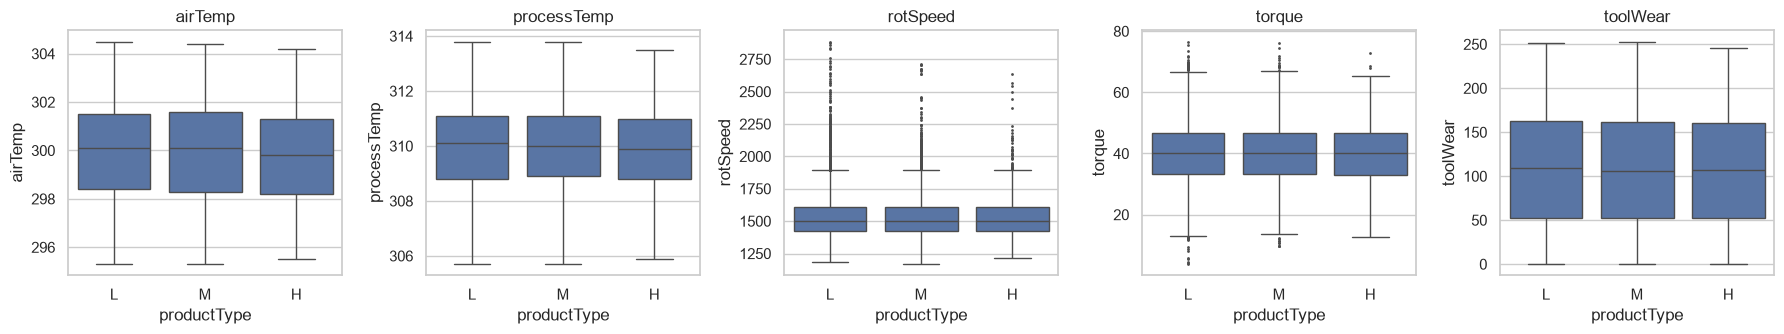

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, col in zip(axes, SENSORS):
    sns.boxplot(df, x="productType", y=col, order=TYPE_ORDER, ax=ax, fliersize=1)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
df.groupby("productType")[SENSORS].mean().loc[TYPE_ORDER].round(2)

,airTemp,processTemp,rotSpeed,torque,toolWear
productType,,,,,
L,300.02,310.01,1539.47,40.00,108.38
M,300.03,310.02,1537.60,40.02,107.27
H,299.87,309.93,1538.15,39.84,107.42


## 7. 센서 간 상관관계

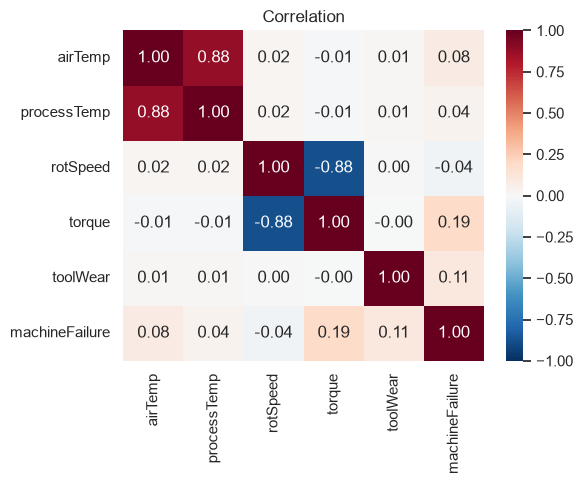

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[SENSORS + ["machineFailure"]].corr(), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation")
plt.tight_layout()
plt.show()

## 8. 정리

**데이터 품질**
- 결측치 0, 중복 0. `productId`가 10,000개 모두 달라서 한 설비를 시간순으로 추적한 데이터가 아니다 (README 한계점의 근거).

**불균형**
- 고장 3.39%. 전부 "정상"이라고만 해도 정확도가 96.6% → 정확도는 지표로 쓰지 않고 정밀도, 재현율, F1을 쓴다.

**라벨 불일치** (정답 기준을 정할 때 반영할 것)
- RNF 19건 중 18건은 `machineFailure = 0`. RNF는 사실상 고장 라벨에 포함되지 않는다.
- 고장인데 유형 라벨이 없는 행 9건. 룰 엔진으로는 원리상 맞힐 수 없다.
- 여러 유형이 동시에 발생한 행 24건. PWF+OSF(11), HDF+OSF(6)이 많다.

**센서 분포**
- 정상/고장 차이가 큰 센서는 torque(평균 39.6 → 50.2), toolWear(106.7 → 143.8), rotSpeed.
- 고장 쪽 torque는 봉우리가 둘이다. 낮은 쪽(< 20 Nm)과 높은 쪽 → 전력이 너무 낮거나 높은 PWF와 관련 있을 것으로 보인다.
- toolWear는 200~240분 구간에 고장이 몰려 있다 (TWF, OSF).
- 단일 센서와 고장의 선형 상관은 최대 0.19로 약하다. 센서 하나만 봐서는 구분이 어렵다 → 센서를 조합한 파생변수가 필요하다는 근거.
- airTemp–processTemp (0.88), rotSpeed–torque (−0.88)는 데이터 생성 방식에서 온 강한 상관이다.

**제품 타입**
- L/M/H 사이에 센서 분포 차이는 거의 없다.
- 고장률은 L 3.92% > M 2.77% > H 2.09%이고, 차이는 대부분 OSF에서 난다 (L 87건, M 9건, H 2건).
  OSF 임계값이 L에서 가장 낮은 것(11,000 < 12,000 < 13,000)과 맞는다 → 룰 엔진은 제품 타입별 임계값이 필요하다.

**다음**: `02_features.ipynb`에서 tempDiff, power, wearTorque로 고장 유형이 분리되는지 확인한다.